<a href="https://colab.research.google.com/github/felipe-lim4/study-ml-classification/blob/main/classificacao_validacao_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/fontes/emp_automovel.csv')
data

# variaveis categoricas: telefone_trab, avaliação_cidade
# variaveis numericas: receita_cliente, anuidade_emprestimo, anos_casa_propria, score_1, score_2, score_3, score_social, troca_telefone

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [4]:

print((data['inadimplente'] == 0).sum())
print((data['inadimplente'] == 1).sum())

49309
4716


### Separando variaveis alvo e explicativas

In [5]:
x = data.drop('inadimplente', axis=1) # Retira a coluna de inadimplente
y = data['inadimplente']

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
tree_model = DecisionTreeClassifier()
# IMPORTANTE: Caso as variaveis não fossem numericas, seria necessario fazer a conversão das variaveis categoricas (OneHotEncoder)
tree_model.fit(x,y)


DecisionTreeClassifier()

### Possivel overfitt

O score dos dados de treinamento com profundidade maxima da arvore foi == 1, indicando que ele acerta 100% dos casos. No entando, isso provavelmente indica que o modelo está simplesmente decorando os resultados, o melhor caminho seria verificar se isso é veridico testando com dados de teste, que não foram utilizados no treinamento.

In [8]:
print(f'acurácia do modelo (profundidade máxima): {tree_model.score(x,y)}')

acurácia do modelo (profundidade máxima): 1.0


### Separação de dados - Treino, Validação e Teste

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Treino e validação
# Stratify mantém as proporções em treino e validação
# Text size é a proporção para cada 1, neste caso é 15% para validação
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify = y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify = y, random_state=5)


In [11]:
# Sem parâmetros com profundidade máxima
model_tree = DecisionTreeClassifier()
model_tree.fit(x_treino, y_treino)

DecisionTreeClassifier()

In [12]:
model_tree = DecisionTreeClassifier(max_depth=4)
model_tree.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=4)

In [13]:
# Verificando acuracia
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_treino,y_treino)}')
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_val,y_val)}')
print(f'acurácia do modelo (profundidade máxima): {model_tree.score(x_teste,y_teste)}')

acurácia do modelo (profundidade máxima): 0.912862950058072
acurácia do modelo (profundidade máxima): 0.9127253723543245
acurácia do modelo (profundidade máxima): 0.9125123395853899


#### Análise de desempenho e Holdout
Há uma discrepancia entre as acurácias, o modelo de treino fica muito a frente, possivalmente pela decora dos resultados.

Fazendo uso o max_depth = 3, conseguimos fazer a poda da arvore, evitando que o modelo decore os dados, aumentando a acurácia nos dados de validação, fazendo o dado de score do treino e validação ficarem semelhantes entre si.

### Entendendo os resultados: Matriz de Confusão
Vamos avaliar quais dados o modelo trás como inadimplente ou não por meio da matriz de confusão, que mede positivos, negativos, falsos positivos e falsos negativos

In [14]:
from sklearn.metrics import confusion_matrix

In [15]:
y_previsto = model_tree.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(f'matriz de confusão: \n{matriz_confusao}')

matriz de confusão: 
[[10479     0]
 [ 1002     0]]


In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

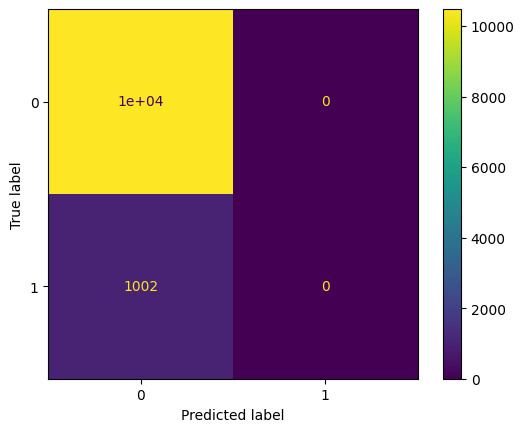

In [17]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot()

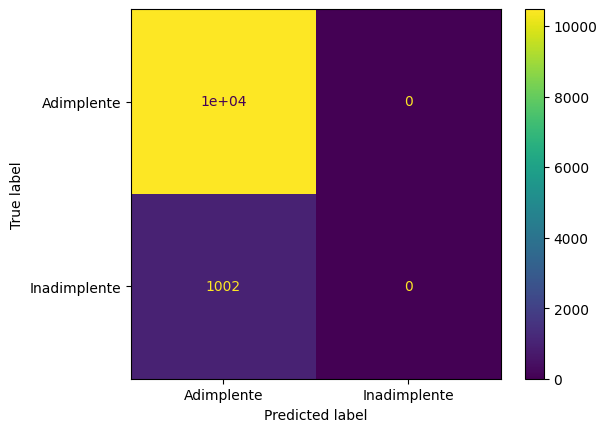

In [18]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', "Inadimplente"])
visualizacao.plot()

Até ai já deu pra perceber que a acurácia por si só não serve como avaliação unica e exclusiva de que o modelo está bom. O problema raiz é a detecção automatica de cliente inadimplentes, mas ele erra por muito a quantidade de clientes inadimplentes.

In [41]:
vn = matriz_confusao[0,0]  # Real: 0, Predito: 0 (Verdadeiro Negativo)
fp = matriz_confusao[0,1]  # Real: 0, Predito: 1 (Falso Positivo)
fn = matriz_confusao[1,0]  # Real: 1, Predito: 0 (Falso Negativo)
vp = matriz_confusao[1,1]  # Real: 1, Predito: 1 (Verdadeiro Positivo)

print(f'Verdadeiros positivos: {vp}')
print(f'Falsos positivos: {fp}')
print(f'Verdadeiros negativos: {vn}')
print(f'Falsos negativos: {fn}')


# Vamos para uma ánalise mais detalhada, da para ver que ele erra muito ao tentar acertar verdadeiro negativo.
# O Recall luta contra os Falsos Negativos. Ele quer reduzir os Falsos Negativos a zero para garantir que o modelo não deixe passar nada.

# A Precisão luta contra os Falsos Positivos. Ela quer reduzir os Falsos Positivos a zero para garantir que o modelo não dê nenhum alarme falso.

print('\n\nRecall ou TPR (% vp comparada ao total de positivos reais):', vp/(vp+fn))
print('Precisão ou assertividade positiva (% de vp comparada a quantidade de acertos preditos pelo modelo)', vp/(vp+fp))
print(f'Acurácia do modelo (profundidade máxima): {model_tree.score(x_treino,y_treino)}')

Verdadeiros positivos: 47
Falsos positivos: 150
Verdadeiros negativos: 10329
Falsos negativos: 955


Recall ou TPR (% vp comparada ao total de positivos reais): 0.046906187624750496
Precisão ou assertividade positiva (% de vp comparada a quantidade de acertos preditos pelo modelo) 0.23857868020304568
Acurácia do modelo (profundidade máxima): 0.912862950058072


## Os dados podem mentir! - Dados desbalanceados e um overfit pesado
Como meus dados eram majoritariamente compostos por valores positivos, o modelo acabou por decorar os caminhos e chutar sempre positivos. O resultado bruto disso é que a acurácia ficou boa, a precisão ficou boa e o recall ficou excelente, mas em compensação, quando negativo ele não acertou nenhuma.

## Random Forest Classifier - Testando outros modelos

Para a avaliação de modelos de forma eficaz, é importante que seja testado em mais de um, para que haja comparação da eficiencia.

A ideia do ramdom forest é decidir com não apenas uma arvore, mas diversas arvores, a que aparecer mais a classificação indicada, será escolhida como resultado.

##### Feature bagging

Cada arvore tem permissão de usar apenas uma quantidade determinada de features, fazendo assim com que os nós não sejam iguais nunca! Outro ponto é que a random forest treina as arvores com partes diferentes do código, podendo até mesmo pergar linhas repetidas, mas sempre mantendo algumas de fora, para pegar todos os padrões que podem haver no dataset.

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
random_forest = RandomForestClassifier(max_depth=3)
random_forest.fit(x_treino, y_treino)
random_forest.score(x_val, y_val)

0.9127253723543245

In [22]:
print(f'acurácia treino profundidade 3: {random_forest.score(x_treino,y_treino)}')
print(f'acurácia avaliação profundidade 3: {random_forest.score(x_val,y_val)}')
print(f'acurácia teste profundidade 3: {random_forest.score(x_teste,y_teste)}')

acurácia treino profundidade 3: 0.9126887340301975
acurácia avaliação profundidade 3: 0.9127253723543245
acurácia teste profundidade 3: 0.9127591312931885


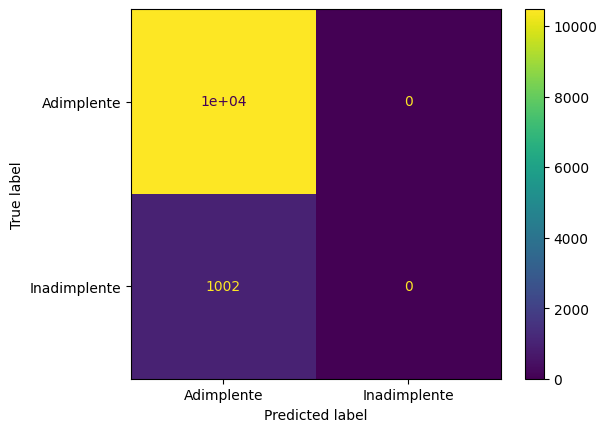

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

y_previsto = random_forest.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)

visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', "Inadimplente"])
visualizacao.plot()


Resultados iguais! Provavelmente é a profundida, vamos testar?

In [25]:
random_forest = RandomForestClassifier(max_depth=12)
random_forest.fit(x_treino, y_treino)

tree =  DecisionTreeClassifier(max_depth=12)
tree.fit(x_treino, y_treino)



acurácia treino profundidade 12: 0.9178861788617886
acurácia avaliação profundidade 12: 0.9128995732079087


In [26]:
print(f'acurácia treino profundidade 12 random_fores: {random_forest.score(x_treino,y_treino)}')
print(f'acurácia avaliação profundidade 12 random_forest: {random_forest.score(x_val,y_val)}')
print(f'acurácia treino profundidade 12 arvore: {tree.score(x_treino,y_treino)}')
print(f'acurácia avaliação profundidade 12 arvore: {tree.score(x_val,y_val)}')


acurácia treino profundidade 12: 0.9178861788617886
acurácia avaliação profundidade 12: 0.9128995732079087
acurácia treino profundidade 12: 0.925842044134727
acurácia avaliação profundidade 12: 0.9037540283947392


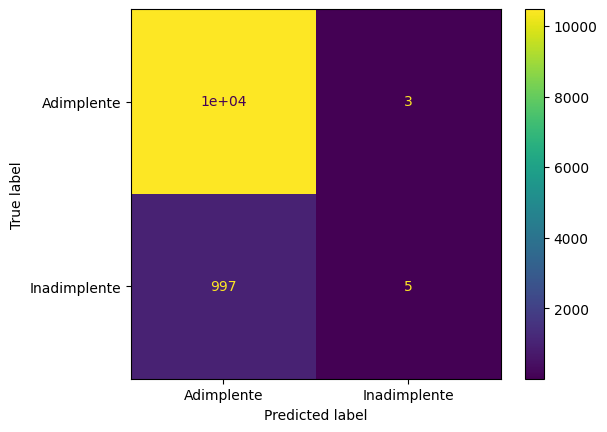

In [29]:
y_previsto = random_forest.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', "Inadimplente"])
visualizacao.plot()

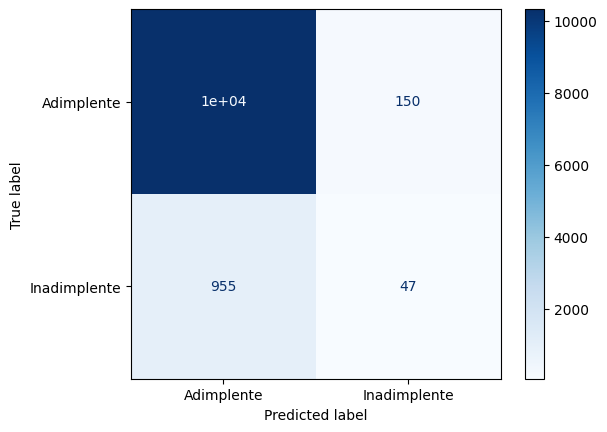

In [36]:
y_previsto = tree.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', "Inadimplente"])
import matplotlib.pyplot as plt
visualizacao.plot(cmap=plt.cm.Blues)
plt.show()

In [37]:
import pandas as pd

df_matriz = pd.DataFrame(
    matriz_confusao,
    columns=['Predito: 0', 'Predito: 1'],
    index=['Real: 0', 'Real: 1']
)

print(df_matriz)

         Predito: 0  Predito: 1
Real: 0       10329         150
Real: 1         955          47


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [38]:
print('Random Forest')
print(f'Acurácia: {accuracy_score(y_val, y_previsto)}')
print(f'Precisão: {precision_score(y_val, y_previsto)}')
print(f'Recall: {recall_score(y_val, y_previsto)}')
print(f'F1: {f1_score(y_val, y_previsto)}')

vn, fp, fn, vp = matriz_confusao.ravel()



#f1 score balanceia os resultados de precisão e recall, sendo mais relevante que a acuracia na maioria dos casos


Random Forest
Acurácia: 0.9037540283947392
Precisão: 0.23857868020304568
Recall: 0.046906187624750496
F1: 0.07839866555462886
Precisão ou assertividade positiva (% de vp comparada a quantidade de acertos preditos pelo modelo) 0.23857868020304568


### f1 score é mais importante que a ácuracia quando:
Os dados são desbalanceados: Como no exemplo acima, onde a classe de interesse (fraude, inadimplência, doença rara, intenção de investimento) é a minoria no dataset.

O custo dos erros é alto e assimétrico: Quando errar para um lado (falso positivo) ou para o outro (falso negativo) traz impactos severos para o negócio, e você precisa garantir que o modelo está performando bem na minoria, e não apenas surfando na facilidade de acertar a maioria esmagadora.